In [ ]:
# --- Configuration ---
# Which run indices (into filtered_runs) to plot individual decays from
DECAY_RUN_INDICES = [0, -1]  # e.g. first and last filtered run

# How many decay curves per run (evenly spaced across frequency)
N_DECAYS_PER_RUN = 8

for ri in DECAY_RUN_INDICES:
    r = filtered_runs[ri]
    n = r["n_completed"]
    if "avgi" not in r or "xpts" not in r:
        print(f"Run {ri} ({r['file']}): no avgi/xpts data, skipping")
        continue

    # Pick evenly spaced frequency indices
    indices = np.linspace(0, n - 1, N_DECAYS_PER_RUN, dtype=int)

    ncols = 4
    nrows = int(np.ceil(len(indices) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = np.atleast_2d(axes)
    fig.suptitle(f"{r['file']}  (run {ri})", fontsize=11, y=1.01)

    for j, idx in enumerate(indices):
        ax = axes.flat[j]
        xpts = np.array(r["xpts"][idx], dtype=float)
        avgi = np.array(r["avgi"][idx], dtype=float)

        ax.plot(xpts, avgi, "o", ms=3, alpha=0.7)

        # Overlay fit if params available
        t1_val = float(r["t1_list"][idx])
        offset_val = float(r["offset_list"][idx]) if "offset_list" in r else np.nan
        amp_val = float(r["amp_list"][idx]) if "amp_list" in r else np.nan
        fit_params = np.array([offset_val, amp_val, t1_val])

        if np.all(np.isfinite(fit_params)):
            x_fit = np.linspace(xpts.min(), xpts.max(), 200)
            ax.plot(x_fit, expfunc(x_fit, *fit_params), "r-", lw=1.2)

        freq_val = r["freq_pts"][idx]
        ax.set_xlabel("Time ($\\mu$s)", fontsize=8)
        ax.set_ylabel("I (a.u.)", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.annotate(f"{freq_val:.1f} MHz\n$T_1$={t1_val:.2f} $\\mu$s",
                    xy=(0.95, 0.95), xycoords="axes fraction",
                    ha="right", va="top", fontsize=7,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))

    # Hide unused axes
    for j in range(len(indices), nrows * ncols):
        axes.flat[j].set_visible(False)

    fig.tight_layout()
    plt.show()

# T1 Predist FastFlux — Collate & Analyze

Load all `t1_predist_fastflux_qubit2_*.h5` runs, collate onto a common frequency grid, and produce color plots.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import h5py
from scipy.interpolate import interp1d

from slab_qick_calib.helpers import handy
from slab_qick_calib.analysis.fitting import expfunc
%matplotlib inline
handy.config_figs()

DATA_DIR = Path("C:/_Data/sample_50_new/data")
H5_PATTERN = "t1_predist_fastflux_qubit2_*.h5"

# --- File index range to include (None = all) ---
FILE_IDX_START = None  # e.g. 8
FILE_IDX_STOP = None   # e.g. 13 (exclusive, like Python slicing)

## 1. Load all H5 files

In [ ]:
h5_files = sorted(DATA_DIR.glob(H5_PATTERN))
if FILE_IDX_START is not None or FILE_IDX_STOP is not None:
    h5_files = h5_files[FILE_IDX_START:FILE_IDX_STOP]
print(f"Loading {len(h5_files)} H5 files")

# Load each run
runs = []
for fpath in h5_files:
    with h5py.File(fpath, "r") as f:
        freq_pts = np.array(f["freq_pts"])
        gain_pts = np.array(f["gain_pts"])
        t1_list = np.array(f["t1_list"])
        timestamps = np.array(f["time"])
        n_completed = len(t1_list)
        n_total = len(freq_pts)
        # Only keep completed points
        freq_pts = freq_pts[:n_completed]
        gain_pts = gain_pts[:n_completed]
        
        # Load optional fields
        data = {
            "file": fpath.name,
            "freq_pts": freq_pts,
            "gain_pts": gain_pts,
            "t1_list": t1_list,
            "timestamps": timestamps,
            "n_completed": n_completed,
            "n_total": n_total,
        }
        for key in ["offset_list", "amp_list", "q_offset_list", "q_amp_list",
                    "s_offset_list", "s_amp_list", "avgi", "avgq", "scale_data", "xpts"]:
            if key in f:
                data[key] = np.array(f[key])
        runs.append(data)

for r in runs:
    t0 = datetime.fromtimestamp(r["timestamps"][0]).strftime("%Y-%m-%d %H:%M")
    print(f"  {r['file']}: {r['n_completed']}/{r['n_total']} pts, "
          f"freq=[{r['freq_pts'].min():.1f}..{r['freq_pts'].max():.1f}] MHz, "
          f"start={t0}")

## 2. Filter runs and build common frequency grid

In [4]:
# Minimum number of completed points to include a run
MIN_POINTS = 10

# Optional frequency range (set to None for full range)
FREQ_MIN = None  # e.g. 3000
FREQ_MAX = None  # e.g. 3470

filtered_runs = [r for r in runs if r["n_completed"] >= MIN_POINTS]
print(f"Keeping {len(filtered_runs)}/{len(runs)} runs with >= {MIN_POINTS} points")

# Determine common frequency grid
all_freq_min = min(r["freq_pts"].min() for r in filtered_runs)
all_freq_max = max(r["freq_pts"].max() for r in filtered_runs)
if FREQ_MIN is not None:
    all_freq_min = max(all_freq_min, FREQ_MIN)
if FREQ_MAX is not None:
    all_freq_max = min(all_freq_max, FREQ_MAX)

# Use the densest run's resolution for the common grid
max_pts = max(r["n_completed"] for r in filtered_runs)
n_common = min(max_pts, 300)
freq_common = np.linspace(all_freq_min, all_freq_max, n_common)
print(f"Common grid: {n_common} points, [{all_freq_min:.1f}, {all_freq_max:.1f}] MHz")

Keeping 9/13 runs with >= 10 points
Common grid: 292 points, [2741.5, 3471.4] MHz


## 3. Interpolate all runs onto common grid

In [5]:
n_runs = len(filtered_runs)
t1_grid = np.full((n_runs, n_common), np.nan)
offset_grid = np.full((n_runs, n_common), np.nan)
amp_grid = np.full((n_runs, n_common), np.nan)
run_timestamps = []  # midpoint timestamp per run

for i, r in enumerate(filtered_runs):
    freq = r["freq_pts"]
    order = np.argsort(freq)
    freq_sorted = freq[order]

    # T1
    t1 = r["t1_list"][order]
    interp = interp1d(freq_sorted, t1, bounds_error=False, fill_value=np.nan)
    t1_grid[i] = interp(freq_common)

    # Offset
    if "offset_list" in r:
        vals = r["offset_list"][order]
        interp = interp1d(freq_sorted, vals, bounds_error=False, fill_value=np.nan)
        offset_grid[i] = interp(freq_common)

    # Amplitude
    if "amp_list" in r:
        vals = r["amp_list"][order]
        interp = interp1d(freq_sorted, vals, bounds_error=False, fill_value=np.nan)
        amp_grid[i] = interp(freq_common)

    # Timestamp (midpoint of run)
    ts = r["timestamps"]
    run_timestamps.append((ts[0] + ts[-1]) / 2)

run_timestamps = np.array(run_timestamps)
elapsed_hours = (run_timestamps - run_timestamps[0]) / 3600
print(f"Collated grid shape: {t1_grid.shape}")
print(f"Time span: {elapsed_hours[-1]:.1f} hours")

Collated grid shape: (9, 292)
Time span: 23.2 hours


## 4. T1 heatmap (frequency vs run)

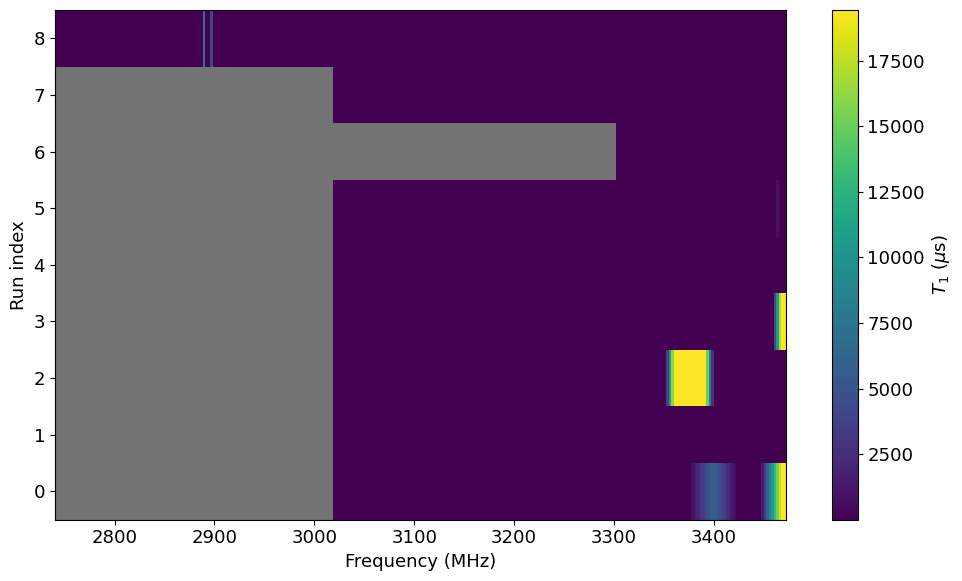

In [6]:
finite = t1_grid[np.isfinite(t1_grid)]
vmin, vmax = np.percentile(finite, [1, 99])

cmap = plt.cm.viridis.copy()
cmap.set_bad(color="0.45")

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(freq_common, np.arange(n_runs), t1_grid,
                   cmap=cmap, vmin=vmin, vmax=vmax, shading="auto", rasterized=True)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Run index")
plt.colorbar(im, ax=ax, label="$T_1$ ($\\mu$s)")
plt.tight_layout()
plt.show()

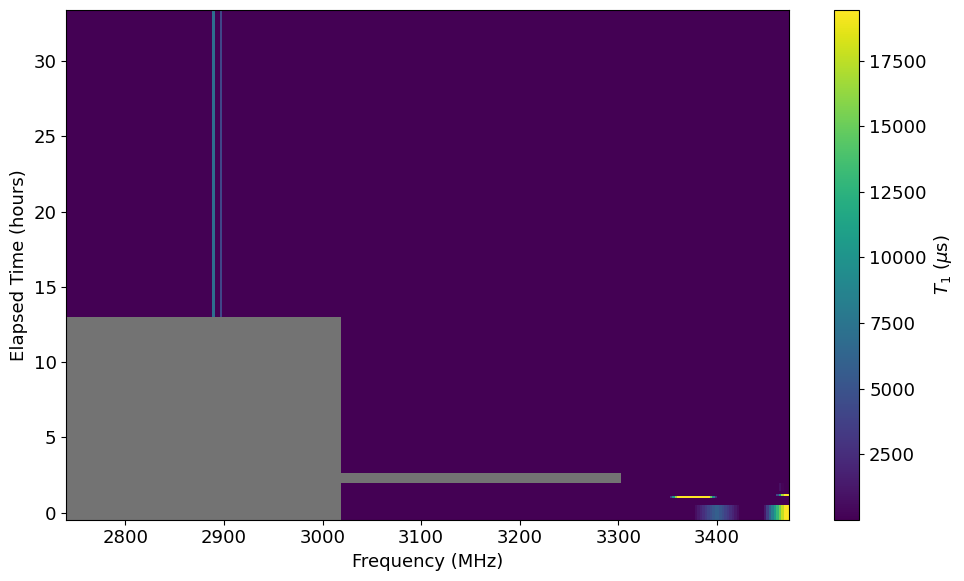

In [7]:
# Same heatmap but with elapsed time on y-axis
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(freq_common, elapsed_hours, t1_grid,
                   cmap=cmap, vmin=vmin, vmax=vmax, shading="auto", rasterized=True)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Elapsed Time (hours)")
plt.colorbar(im, ax=ax, label="$T_1$ ($\\mu$s)")
plt.tight_layout()
plt.show()

## 5. Mean / median T1 vs frequency (time-averaged)

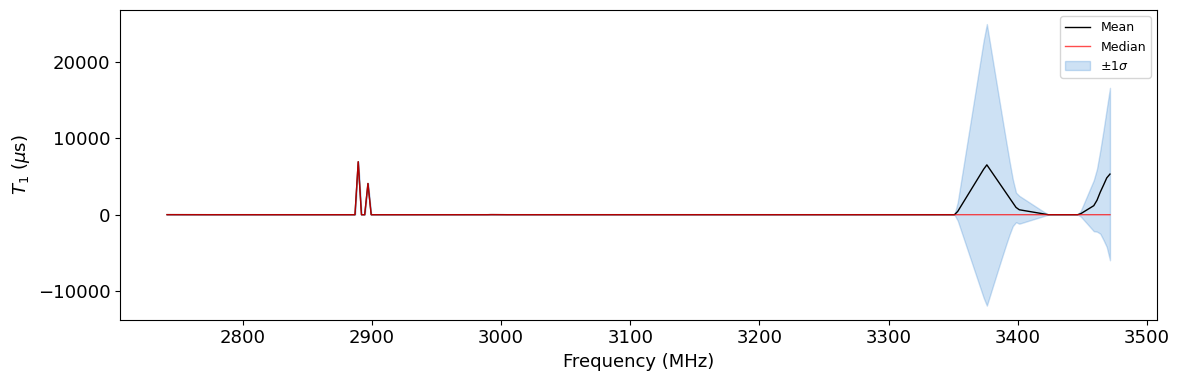

In [8]:
mean_t1 = np.nanmean(t1_grid, axis=0)
std_t1 = np.nanstd(t1_grid, axis=0)
median_t1 = np.nanmedian(t1_grid, axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(freq_common, mean_t1, "k-", lw=1, label="Mean")
ax.plot(freq_common, median_t1, "r-", lw=1, alpha=0.7, label="Median")
ax.fill_between(freq_common, mean_t1 - std_t1, mean_t1 + std_t1,
                alpha=0.2, color="C0", label="$\\pm 1\\sigma$")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("$T_1$ ($\\mu$s)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6. T1 time trace at selected frequencies

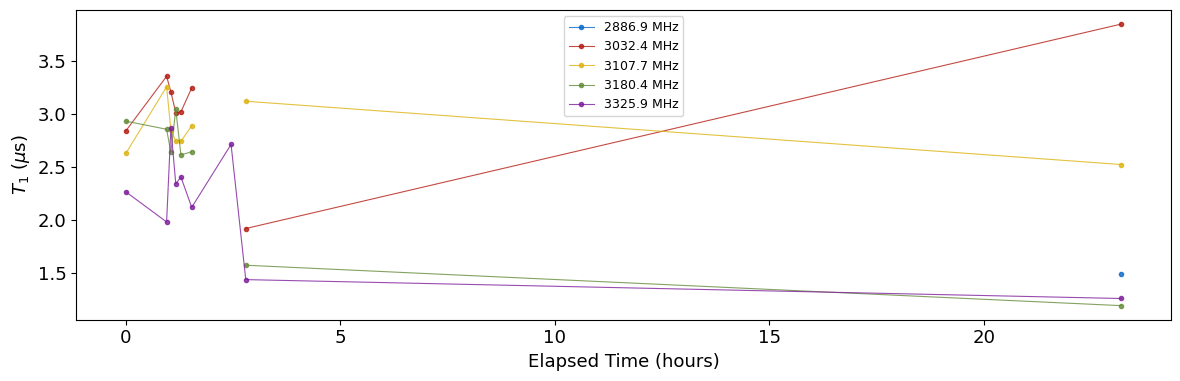

In [9]:
n_freq = len(freq_common)
idx_list = [n_freq // 5, 2 * n_freq // 5, n_freq // 2, 3 * n_freq // 5, 4 * n_freq // 5]

fig, ax = plt.subplots(figsize=(12, 4))
for idx in idx_list:
    ax.plot(elapsed_hours, t1_grid[:, idx], ".-", lw=0.8, alpha=0.8,
            label=f"{freq_common[idx]:.1f} MHz")
ax.set_xlabel("Elapsed Time (hours)")
ax.set_ylabel("$T_1$ ($\\mu$s)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 7. Offset & amplitude heatmaps

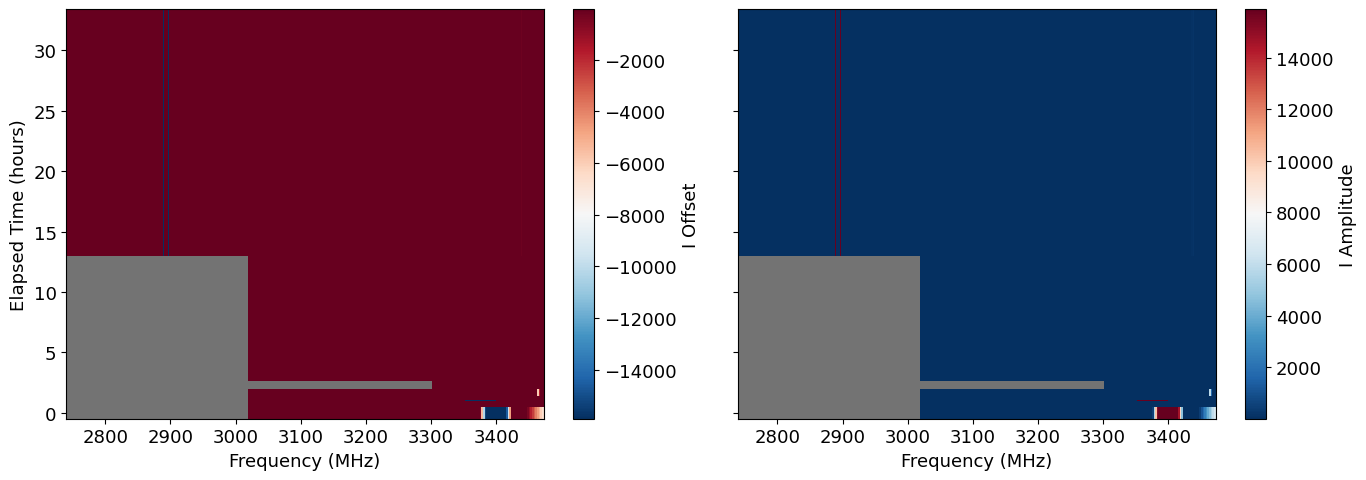

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, grid, label in [(axes[0], offset_grid, "I Offset"),
                         (axes[1], amp_grid, "I Amplitude")]:
    finite_vals = grid[np.isfinite(grid)]
    if len(finite_vals) == 0:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center")
        continue
    v1, v2 = np.percentile(finite_vals, [2, 98])
    cmap_rdb = plt.cm.RdBu_r.copy()
    cmap_rdb.set_bad(color="0.45")
    im = ax.pcolormesh(freq_common, elapsed_hours, grid,
                       cmap=cmap_rdb, vmin=v1, vmax=v2, shading="auto", rasterized=True)
    ax.set_xlabel("Frequency (MHz)")
    plt.colorbar(im, ax=ax, label=label)

axes[0].set_ylabel("Elapsed Time (hours)")
plt.tight_layout()
plt.show()

## 8. Average T1 vs time (all frequencies)

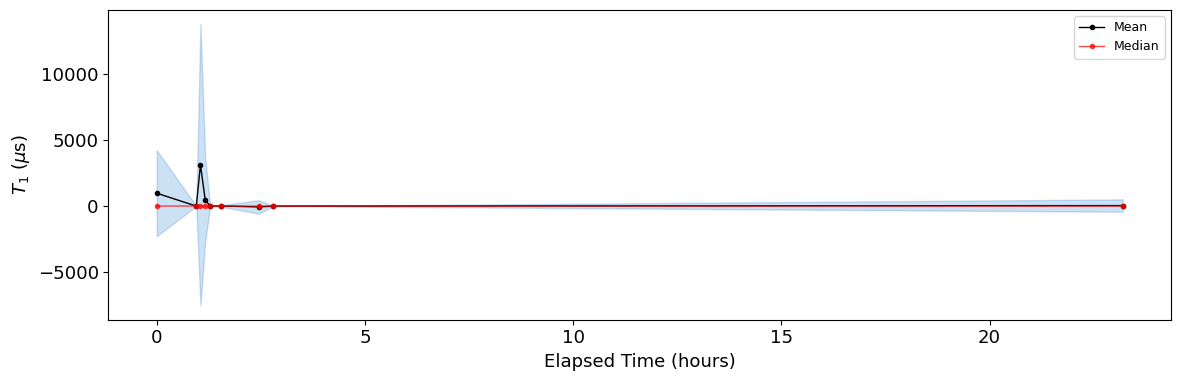

In [11]:
mean_t1_vs_time = np.nanmean(t1_grid, axis=1)
median_t1_vs_time = np.nanmedian(t1_grid, axis=1)
std_t1_vs_time = np.nanstd(t1_grid, axis=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(elapsed_hours, mean_t1_vs_time, "k.-", lw=1, label="Mean")
ax.plot(elapsed_hours, median_t1_vs_time, "r.-", lw=1, alpha=0.7, label="Median")
ax.fill_between(elapsed_hours, mean_t1_vs_time - std_t1_vs_time,
                mean_t1_vs_time + std_t1_vs_time, alpha=0.2, color="C0")
ax.set_xlabel("Elapsed Time (hours)")
ax.set_ylabel("$T_1$ ($\\mu$s)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 9. T1 histogram (all runs pooled)

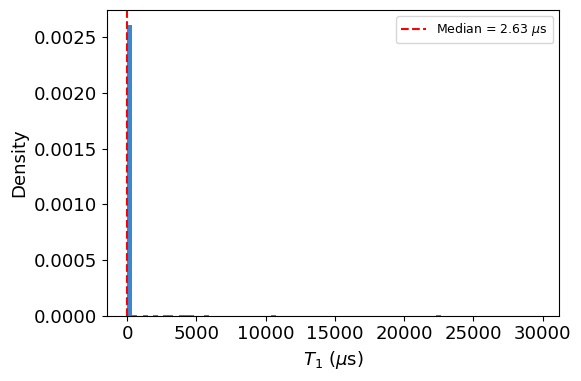

In [12]:
all_t1 = t1_grid[np.isfinite(t1_grid)]
all_t1 = all_t1[(all_t1 > 0) & (all_t1 < np.percentile(all_t1, 99.5))]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(all_t1, bins=80, edgecolor="none", alpha=0.8, density=True)
ax.axvline(np.median(all_t1), color="r", ls="--", lw=1.5,
           label=f"Median = {np.median(all_t1):.2f} $\\mu$s")
ax.set_xlabel("$T_1$ ($\\mu$s)")
ax.set_ylabel("Density")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 10. Individual run overlay

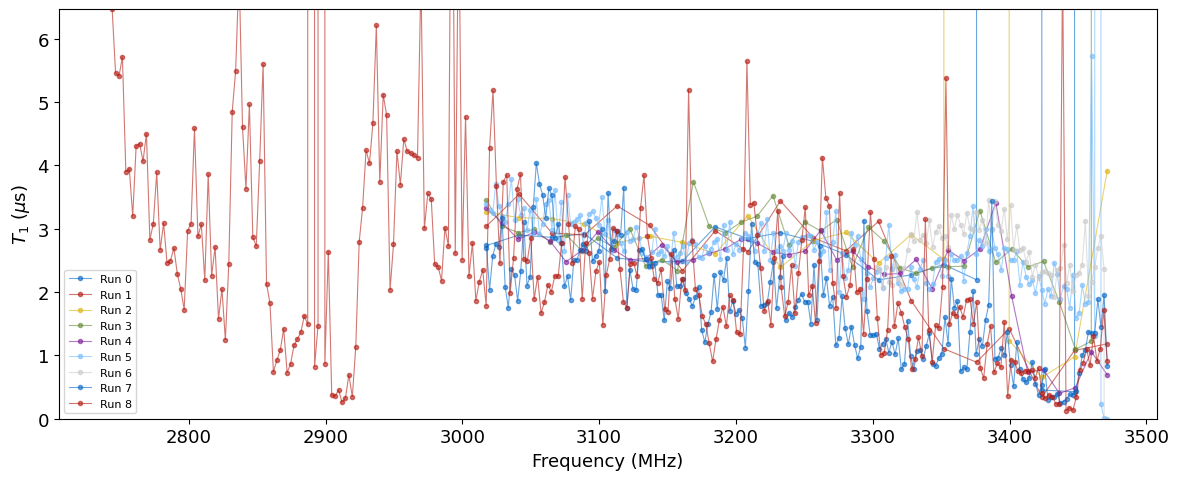

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
for i, r in enumerate(filtered_runs):
    freq = r["freq_pts"]
    t1 = r["t1_list"]
    order = np.argsort(freq)
    ax.plot(freq[order], t1[order], ".-", lw=0.8, alpha=0.6,
            label=f"Run {i}" if i < 10 else None)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("$T_1$ ($\\mu$s)")
# Clip y-axis to inlier range
finite = t1_grid[np.isfinite(t1_grid)]
q1, q3 = np.percentile(finite, [5, 95])
ax.set_ylim(max(0, q1 - 0.5 * (q3 - q1)), q3 + 0.5 * (q3 - q1))
if len(filtered_runs) <= 10:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 11. CSV-based loading (alternative)

Load all CSVs into a single DataFrame for more flexible analysis.

In [14]:
csv_files = sorted(DATA_DIR.glob("t1_predist_fastflux_qubit2_*.csv"))
print(f"Found {len(csv_files)} CSV files")

dfs = []
for fpath in csv_files:
    df = pd.read_csv(fpath)
    df["run"] = int(fpath.stem.split("_")[-1])
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all["timestamp"] = pd.to_datetime(df_all["timestamp"], format="ISO8601")
df_all["hours"] = (df_all["timestamp"] - df_all["timestamp"].min()).dt.total_seconds() / 3600

print(f"Total rows: {len(df_all)}")
print(f"Columns: {list(df_all.columns)}")
df_all.head()

Found 13 CSV files
Total rows: 929
Columns: ['timestamp', 'gain', 'freq', 't1', 'offset', 'amplitude', 'q_offset', 'q_amplitude', 'elapsed_s', 'run', 'hours']


,timestamp,gain,freq,t1,offset,amplitude,q_offset,q_amplitude,elapsed_s,run,hours
0,2026-03-24 18:43:09.715327,0.154600,3471.386900,0.628836,-7.112887,4.551156,-28.074197,3.710241,3.370905,0,0.000000
1,2026-03-24 18:43:12.448985,0.066713,3447.503125,0.398904,-52.856962,18.050269,NaN,NaN,6.104563,0,0.000759
2,2026-03-24 18:43:14.950278,0.030102,3423.619349,0.357331,-51.235728,21.008404,-32.031485,0.856955,8.605856,0,0.001454
3,2026-03-24 18:43:17.323244,0.001859,3399.735574,0.596287,-46.490686,23.688087,-34.332663,4.409059,10.978822,0,0.002113
4,2026-03-24 18:43:19.586462,-0.022086,3375.851798,1.495749,-52.489192,22.910586,-32.448768,3.249362,13.242041,0,0.002742


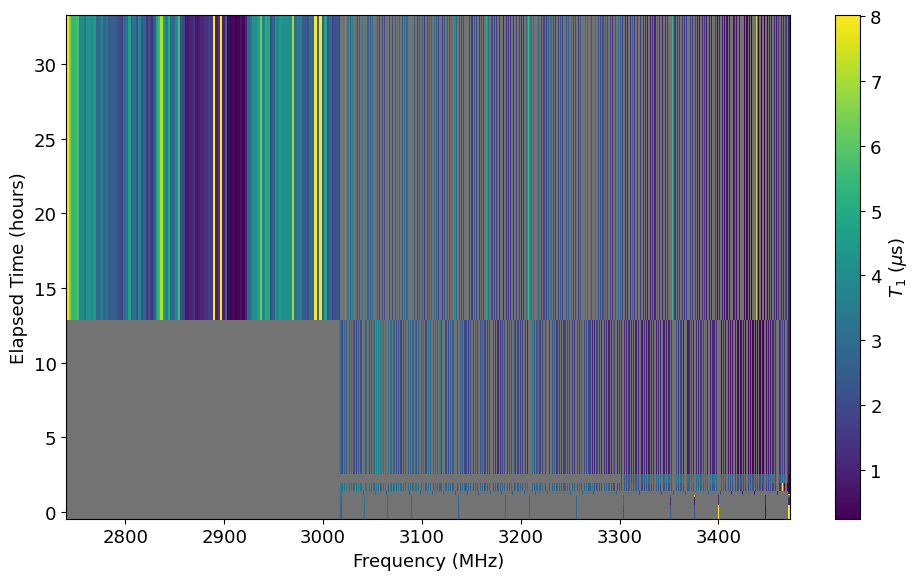

In [15]:
# CSV-based T1 heatmap using pivot
# Filter out runs with too few points
run_counts = df_all.groupby("run").size()
good_runs = run_counts[run_counts >= MIN_POINTS].index
df_good = df_all[df_all["run"].isin(good_runs)].copy()

pivot = df_good.pivot_table(index="run", columns="freq", values="t1", aggfunc="first")
freq_csv = pivot.columns.values
t1_csv_grid = pivot.values

# Hours per run (first timestamp)
run_hours = df_good.groupby("run")["hours"].first().loc[pivot.index].values

finite_csv = t1_csv_grid[np.isfinite(t1_csv_grid)]
vmin_c, vmax_c = np.percentile(finite_csv, [1, 99])

cmap_c = plt.cm.viridis.copy()
cmap_c.set_bad(color="0.45")

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(freq_csv, run_hours, t1_csv_grid,
                   cmap=cmap_c, vmin=vmin_c, vmax=vmax_c, shading="auto", rasterized=True)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Elapsed Time (hours)")
plt.colorbar(im, ax=ax, label="$T_1$ ($\\mu$s)")
plt.tight_layout()
plt.show()

## 12. Individual T1 decay curves

Plot individual T1 decay traces with exponential fits from selected runs.